Epoch 1: Loss=910.22, Acc=0.147
Epoch 2: Loss=795.55, Acc=0.315
Epoch 3: Loss=492.14, Acc=0.660
Epoch 4: Loss=319.48, Acc=0.772
Epoch 5: Loss=246.27, Acc=0.818


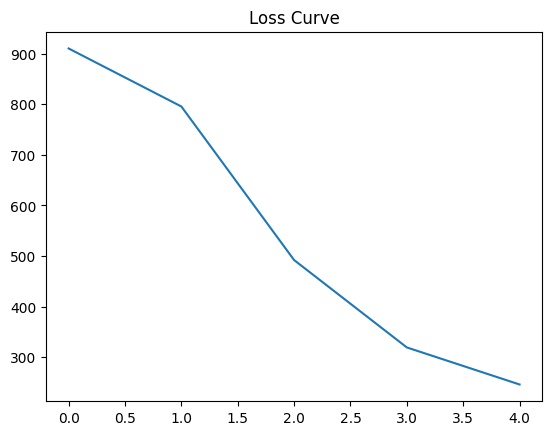

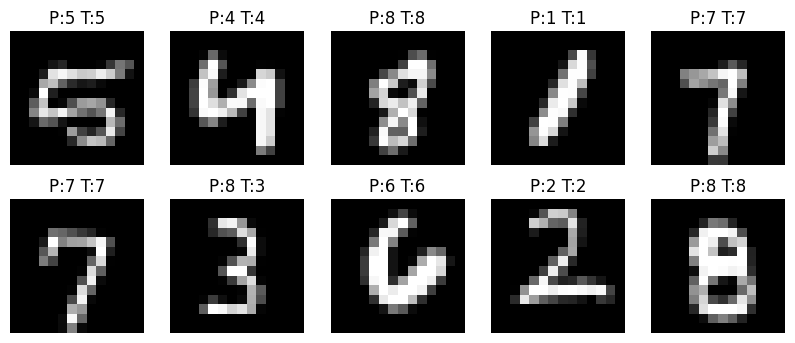

Test Acc: 0.9


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import mnist

np.random.seed(42)

# -----------------------------
# Data utilities
# -----------------------------
def make_balanced_subset(X, y, samples_per_class):
    idx = []
    for c in np.unique(y):
        inds = np.where(y == c)[0]
        np.random.shuffle(inds)
        idx.extend(inds[:samples_per_class])
    idx = np.array(idx)
    np.random.shuffle(idx)
    return X[idx], y[idx]

def downsample(images):
    n = images.shape[0]
    images = images.reshape(n, 28, 28)
    return images.reshape(n, 14, 2, 14, 2).mean(axis=(2,4))

# -----------------------------
# Layers
# -----------------------------
def conv_forward(img, kernels):
    nf, kh, kw = kernels.shape
    h, w = img.shape
    out = np.zeros((nf, h-kh+1, w-kw+1))

    for f in range(nf):
        for i in range(out.shape[1]):
            for j in range(out.shape[2]):
                region = img[i:i+kh, j:j+kw]
                out[f,i,j] = np.sum(region * kernels[f])
    return out

def relu(x):
    return np.maximum(0,x)

def relu_deriv(x):
    return (x>0).astype(float)

def maxpool(x):
    nf,h,w = x.shape
    out = np.zeros((nf,h//2,w//2))

    for f in range(nf):
        for i in range(0,h,2):
            for j in range(0,w,2):
                out[f,i//2,j//2] = np.max(x[f,i:i+2,j:j+2])
    return out

def maxpool_back(dout, x):
    nf,h,w = x.shape
    dx = np.zeros_like(x)

    for f in range(nf):
        for i in range(0,h,2):
            for j in range(0,w,2):
                region = x[f,i:i+2,j:j+2]
                m = np.max(region)
                for a in range(2):
                    for b in range(2):
                        if region[a,b]==m:
                            dx[f,i+a,j+b]+=dout[f,i//2,j//2]
    return dx

def softmax(x):
    e = np.exp(x-np.max(x))
    return e/np.sum(e)

# -----------------------------
# Load data
# -----------------------------
(X,y), _ = mnist.load_data()
X = X.reshape(-1,784)/255.0

X,y = make_balanced_subset(X,y,50)
X = downsample(X)

Xtr,Xte,Ytr,Yte = train_test_split(X,y,test_size=0.2)

# -----------------------------
# Params
# -----------------------------
nf=4
ks=3

kernels = np.random.randn(nf,ks,ks)*0.1

flat_size = nf*6*6
W = np.random.randn(flat_size,10)*0.1
b = np.zeros(10)

lr = 0.01
epochs = 5

losses=[]

# -----------------------------
# Training
# -----------------------------
for ep in range(epochs):
    loss_total=0
    correct=0

    for i in range(len(Xtr)):
        img = Xtr[i]
        label = Ytr[i]

        # forward
        c = conv_forward(img,kernels)
        r = relu(c)
        p = maxpool(r)
        flat = p.reshape(-1)

        logits = flat @ W + b
        probs = softmax(logits)

        loss = -np.log(probs[label]+1e-9)
        loss_total+=loss

        if np.argmax(probs)==label:
            correct+=1

        # backward dense
        dlog = probs.copy()
        dlog[label]-=1

        dW = np.outer(flat,dlog)
        db = dlog

        dflat = W @ dlog
        dp = dflat.reshape(p.shape)

        # backward pool
        dr = maxpool_back(dp,r)

        # backward relu
        dc = dr * relu_deriv(c)

        # backward conv (simple update)
        for f in range(nf):
            for i1 in range(dc.shape[1]):
                for j1 in range(dc.shape[2]):
                    region = img[i1:i1+ks,j1:j1+ks]
                    kernels[f] -= lr * dc[f,i1,j1]*region

        # update dense
        W -= lr*dW
        b -= lr*db

    acc = correct/len(Xtr)
    losses.append(loss_total)
    print(f"Epoch {ep+1}: Loss={loss_total:.2f}, Acc={acc:.3f}")

# -----------------------------
# Plot loss
# -----------------------------
plt.plot(losses)
plt.title("Loss Curve")
plt.show()

# -----------------------------
# Test + show predictions
# -----------------------------
correct=0

plt.figure(figsize=(10,4))

for i in range(10):
    img = Xte[i]
    label = Yte[i]

    c = conv_forward(img,kernels)
    r = relu(c)
    p = maxpool(r)
    flat = p.reshape(-1)

    pred = np.argmax(softmax(flat@W+b))

    if pred==label:
        correct+=1

    plt.subplot(2,5,i+1)
    plt.imshow(img.reshape(14,14),cmap='gray')
    plt.title(f"P:{pred} T:{label}")
    plt.axis('off')

plt.show()

print("Test Acc:",correct/10)